# Análise Exploratória de Dados (EDA)

Neste notebook, faremos uma análise exploratória da base de dados do Kaggle e a preparação inicial.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## 1. Carregamento dos Dados

In [2]:
# O dataset bank-additional-full utiliza ponto e vírgula como separador
df = pd.read_csv('../data/bank-additional-full.csv', sep=';')
display(df.head())

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 2. Visão Geral dos Dados

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [ ]:
# Checando valores nulos (essa base não costuma ter valores nulos puros, e sim categóricos como 'unknown')
display(df.isnull().sum())

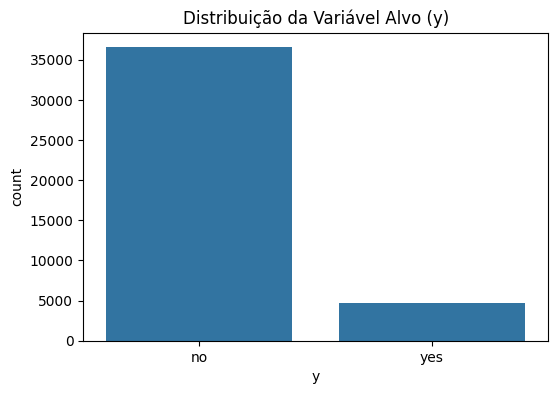

Proporção de conversões:
y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64


In [4]:
# Proporção da variável alvo (conversão)
plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=df)
plt.title('Distribuição da Variável Alvo (y)')
plt.show()

print("Proporção de conversões:")
print(df['y'].value_counts(normalize=True) * 100)

## 3. Tratamento de Dados e Vazamento Temporal (Data Leakage)
Conforme indicado nas regras do Datathon:
*"Descarte colunas de vazamento temporal (ex.: duration no Bank Marketing)"*.
A duração do contato só é conhecida *após* a realização do contato, portanto não podemos usá-la em um modelo que toma decisão *antes* de enviar a mensagem.

In [5]:
# Removendo a coluna duration
if 'duration' in df.columns:
    df = df.drop(columns=['duration'])
    print("Coluna 'duration' removida com sucesso para evitar vazamento temporal.")

Coluna 'duration' removida com sucesso para evitar vazamento temporal.


## 4. Codificação da Variável Alvo

In [6]:
# Transformando a variável alvo em valores binários (1 para 'yes', 0 para 'no')
df['target'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)
df = df.drop(columns=['y'])

print("Alvo convertido para numérico (1 = yes, 0 = no).")
display(df['target'].value_counts())

Alvo convertido para numérico (1 = yes, 0 = no).


target
0    36548
1     4640
Name: count, dtype: int64

## 5. Salvando a Base Inicial para as Próximas Etapas
Vamos salvar esta base já sem o vazamento temporal e com o target formatado.

In [7]:
df.to_csv('../data/bank_cleaned.csv', index=False)
print("Base limpa salva em 'data/bank_cleaned.csv'!")

Base limpa salva em 'data/bank_cleaned.csv'!
